# Step 35 — Pearson's r Feature Screening

Scope: screening only, NOT a full model build. Target is always fixed:
`close_log_return`. For each candidate feature, compute Pearson's r and
p-value against the target, using Train data only (same 75/25 chronological
split discipline as everywhere else), with `close_log_return_lag_1`
(Model A's own feature) kept as the benchmark to beat.

Every candidate must be a **lagged** value (known before the day it's
predicting) — no same-day/lookahead features.

If a candidate beats the benchmark with a statistically meaningful r/p, the
next step (separate, later notebook) is building and evaluating an actual
regression model with it — full Train/Test/WFA rigor, same as notebook 31.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

plt.style.use('dark_background')


def compute_rsi(close, period=14):
    """Standard Wilder-smoothed RSI."""
    delta = close.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def build_features(daily):
    """daily must have a 'c' (close) column. Adds target + all candidate features."""
    daily['close_log_return'] = np.log(daily['c'] / daily['c'].shift())
    daily['close_log_return_lag_1'] = daily['close_log_return'].shift()          # benchmark
    daily['rsi'] = compute_rsi(daily['c'])
    daily['rsi_lag_1'] = daily['rsi'].shift()                                    # candidate
    return daily


def screen(daily, candidates, target='close_log_return', test_split=0.25):
    """Train-only Pearson r/p for each candidate vs target. Returns (results_df, train_df)."""
    from sklearn.model_selection import train_test_split
    df = daily.dropna(subset=candidates + [target])
    train, _ = train_test_split(df, test_size=test_split, shuffle=False)
    rows = []
    for c in candidates:
        r, p = st.pearsonr(train[c], train[target])
        rows.append({'feature': c, 'n': len(train), 'r': round(r, 4), 'p': round(p, 4),
                     'significant (p<0.05)': p < 0.05})
    return pd.DataFrame(rows), train

## NIFTY50

In [2]:
nifty = pd.read_parquet('../../../../data/historical/daily/NIFTY50.parquet')
nifty['datetime'] = pd.to_datetime(nifty['datetime'])
if nifty['datetime'].dt.tz is not None:
    nifty['datetime'] = nifty['datetime'].apply(lambda x: x.replace(tzinfo=None))
nifty.set_index('datetime', inplace=True)
nifty.rename(columns={'close': 'c'}, inplace=True)
nifty = nifty[['c']]
nifty = build_features(nifty)

candidates = ['close_log_return_lag_1', 'rsi_lag_1']
results_nifty, train_nifty = screen(nifty, candidates)
print('NIFTY50 — Train n:', len(train_nifty))
results_nifty

NIFTY50 — Train n: 2123


,feature,n,r,p,significant (p<0.05)
0,close_log_return_lag_1,2123,-0.0204,0.3465,False
1,rsi_lag_1,2123,0.0212,0.3281,False


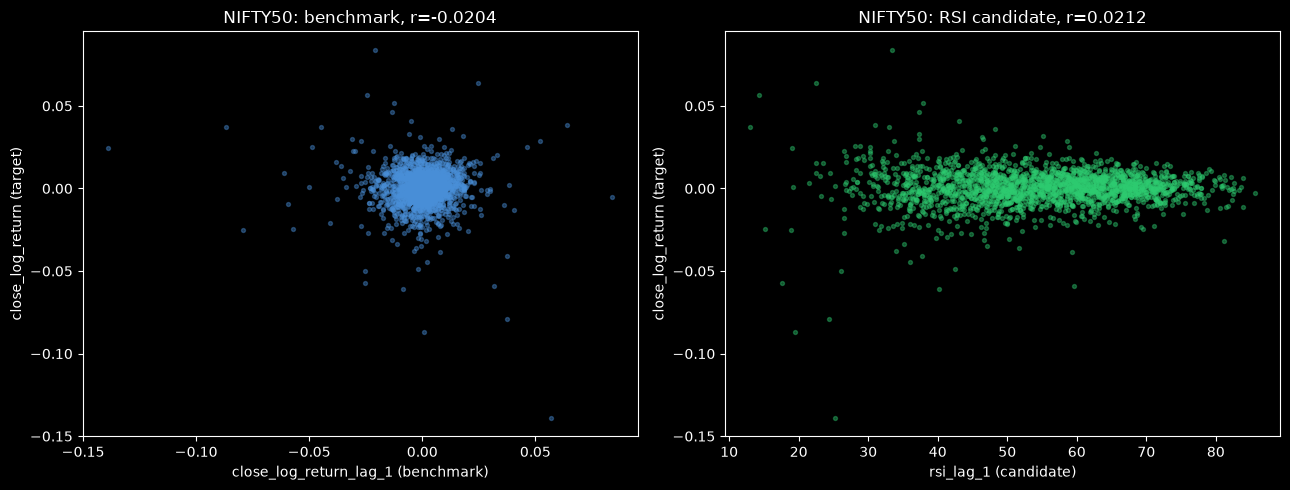

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(train_nifty['close_log_return_lag_1'], train_nifty['close_log_return'], s=8, alpha=0.4, color='#4a90d9')
axes[0].set_xlabel('close_log_return_lag_1 (benchmark)')
axes[0].set_ylabel('close_log_return (target)')
axes[0].set_title(f"NIFTY50: benchmark, r={results_nifty.loc[0,'r']}")

axes[1].scatter(train_nifty['rsi_lag_1'], train_nifty['close_log_return'], s=8, alpha=0.4, color='#2ecc71')
axes[1].set_xlabel('rsi_lag_1 (candidate)')
axes[1].set_ylabel('close_log_return (target)')
axes[1].set_title(f"NIFTY50: RSI candidate, r={results_nifty.loc[1,'r']}")
plt.tight_layout()
plt.show()

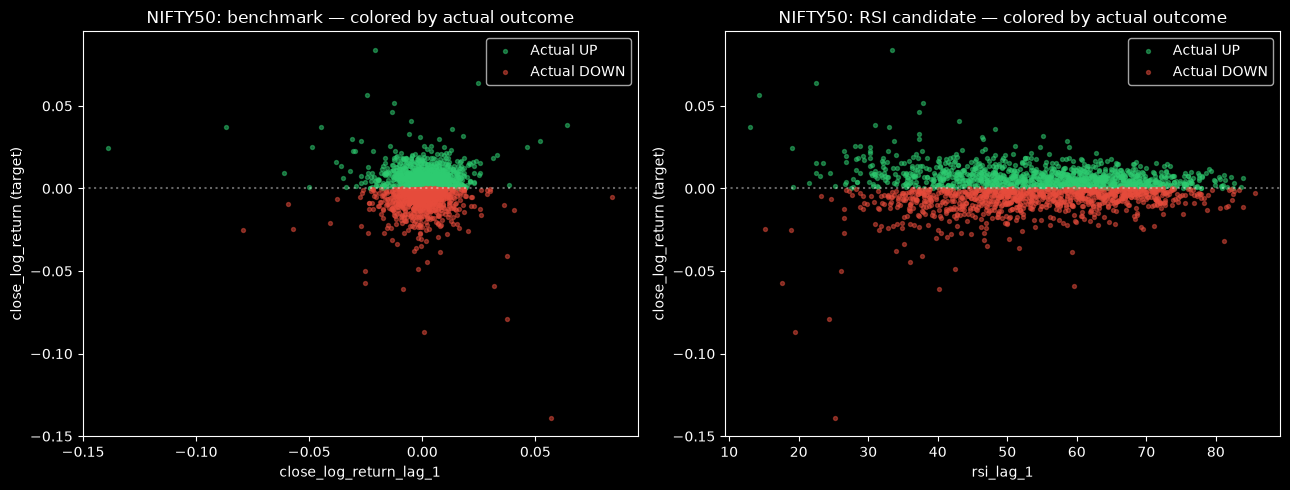

In [4]:
up = train_nifty[train_nifty['close_log_return'] > 0]
down = train_nifty[train_nifty['close_log_return'] <= 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat, title in [(axes[0], 'close_log_return_lag_1', 'benchmark'), (axes[1], 'rsi_lag_1', 'RSI candidate')]:
    ax.scatter(up[feat], up['close_log_return'], s=8, alpha=0.5, color='#2ecc71', label='Actual UP')
    ax.scatter(down[feat], down['close_log_return'], s=8, alpha=0.5, color='#e74c3c', label='Actual DOWN')
    ax.axhline(0, color='white', linestyle=':', alpha=0.4)
    ax.set_xlabel(feat)
    ax.set_ylabel('close_log_return (target)')
    ax.set_title(f'NIFTY50: {title} — colored by actual outcome')
    ax.legend()
plt.tight_layout()
plt.show()

## TATAMOTORS

In [5]:
bars = pd.read_parquet('../../../../data/historical/intraday_5min_DS3/TATAMOTORS.parquet', columns=['datetime', 'close'])
bars['datetime'] = pd.to_datetime(bars['datetime'])
if bars['datetime'].dt.tz is not None:
    bars['datetime'] = bars['datetime'].apply(lambda x: x.replace(tzinfo=None))
tata = bars.set_index('datetime')['close'].resample('D').last().dropna().to_frame()
tata.rename(columns={'close': 'c'}, inplace=True)
tata = build_features(tata)

results_tata, train_tata = screen(tata, candidates)
print('TATAMOTORS — Train n:', len(train_tata))
results_tata

TATAMOTORS — Train n: 2097


,feature,n,r,p,significant (p<0.05)
0,close_log_return_lag_1,2097,-0.0087,0.6888,False
1,rsi_lag_1,2097,0.0548,0.0120,True


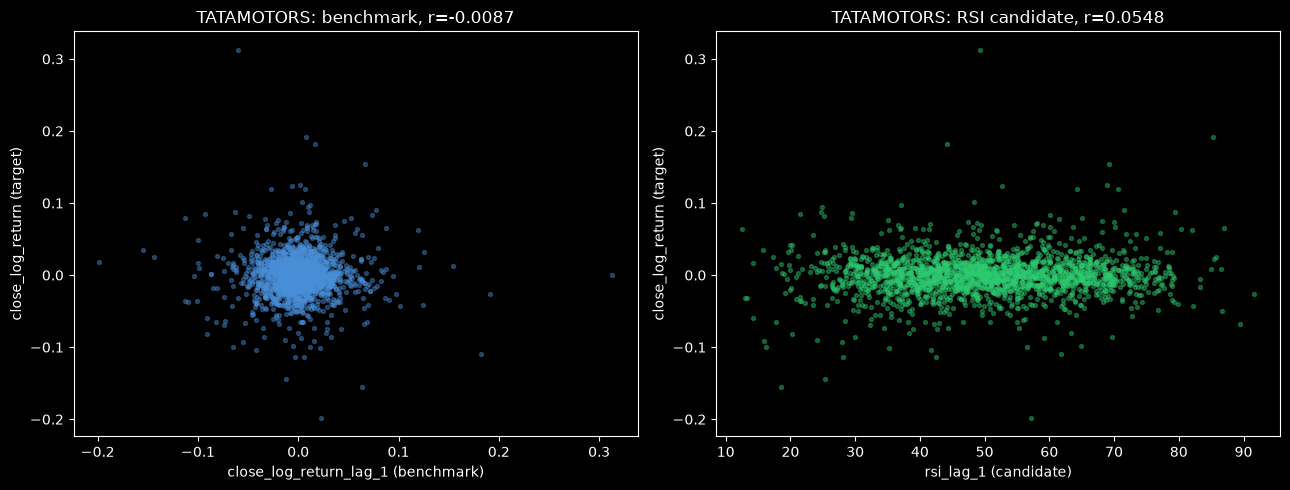

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(train_tata['close_log_return_lag_1'], train_tata['close_log_return'], s=8, alpha=0.4, color='#4a90d9')
axes[0].set_xlabel('close_log_return_lag_1 (benchmark)')
axes[0].set_ylabel('close_log_return (target)')
axes[0].set_title(f"TATAMOTORS: benchmark, r={results_tata.loc[0,'r']}")

axes[1].scatter(train_tata['rsi_lag_1'], train_tata['close_log_return'], s=8, alpha=0.4, color='#2ecc71')
axes[1].set_xlabel('rsi_lag_1 (candidate)')
axes[1].set_ylabel('close_log_return (target)')
axes[1].set_title(f"TATAMOTORS: RSI candidate, r={results_tata.loc[1,'r']}")
plt.tight_layout()
plt.show()

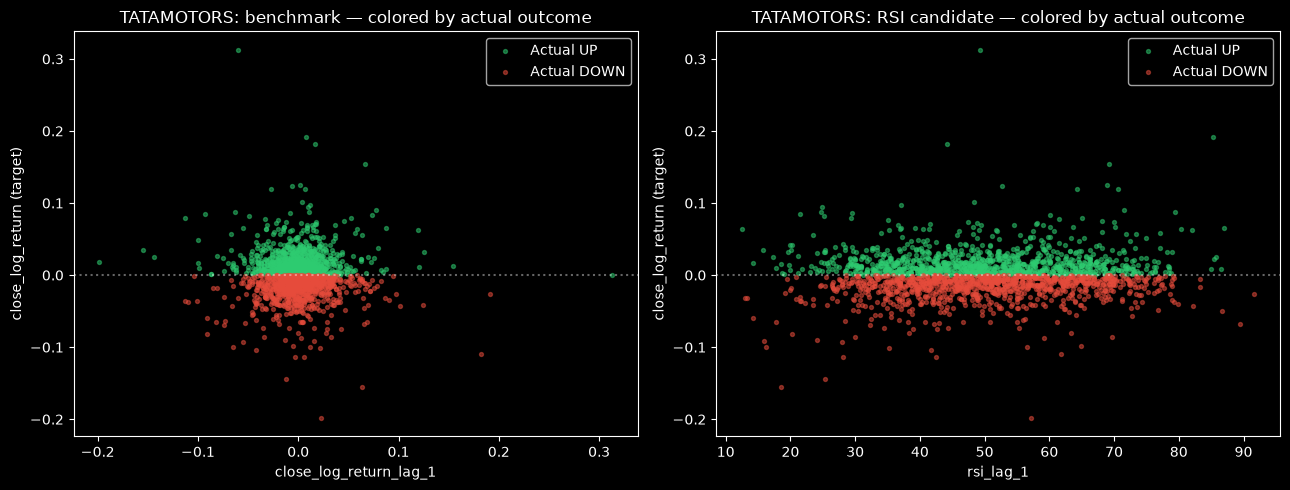

In [7]:
up_t = train_tata[train_tata['close_log_return'] > 0]
down_t = train_tata[train_tata['close_log_return'] <= 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat, title in [(axes[0], 'close_log_return_lag_1', 'benchmark'), (axes[1], 'rsi_lag_1', 'RSI candidate')]:
    ax.scatter(up_t[feat], up_t['close_log_return'], s=8, alpha=0.5, color='#2ecc71', label='Actual UP')
    ax.scatter(down_t[feat], down_t['close_log_return'], s=8, alpha=0.5, color='#e74c3c', label='Actual DOWN')
    ax.axhline(0, color='white', linestyle=':', alpha=0.4)
    ax.set_xlabel(feat)
    ax.set_ylabel('close_log_return (target)')
    ax.set_title(f'TATAMOTORS: {title} — colored by actual outcome')
    ax.legend()
plt.tight_layout()
plt.show()

### TATAMOTORS RSI — rolling-correlation stability check

Same diagnostic as POWERGRID's — rolling 1-year (252 trading day) Pearson r/p
across TATAMOTORS' full history, using the full dataset (not just Train).

TATAMOTORS rolling 1yr r — min: -0.1288 | max: 0.1831 | mean: 0.0042 | ever crosses 0: True
windows with p<0.05: 3.7% | median p: 0.5995


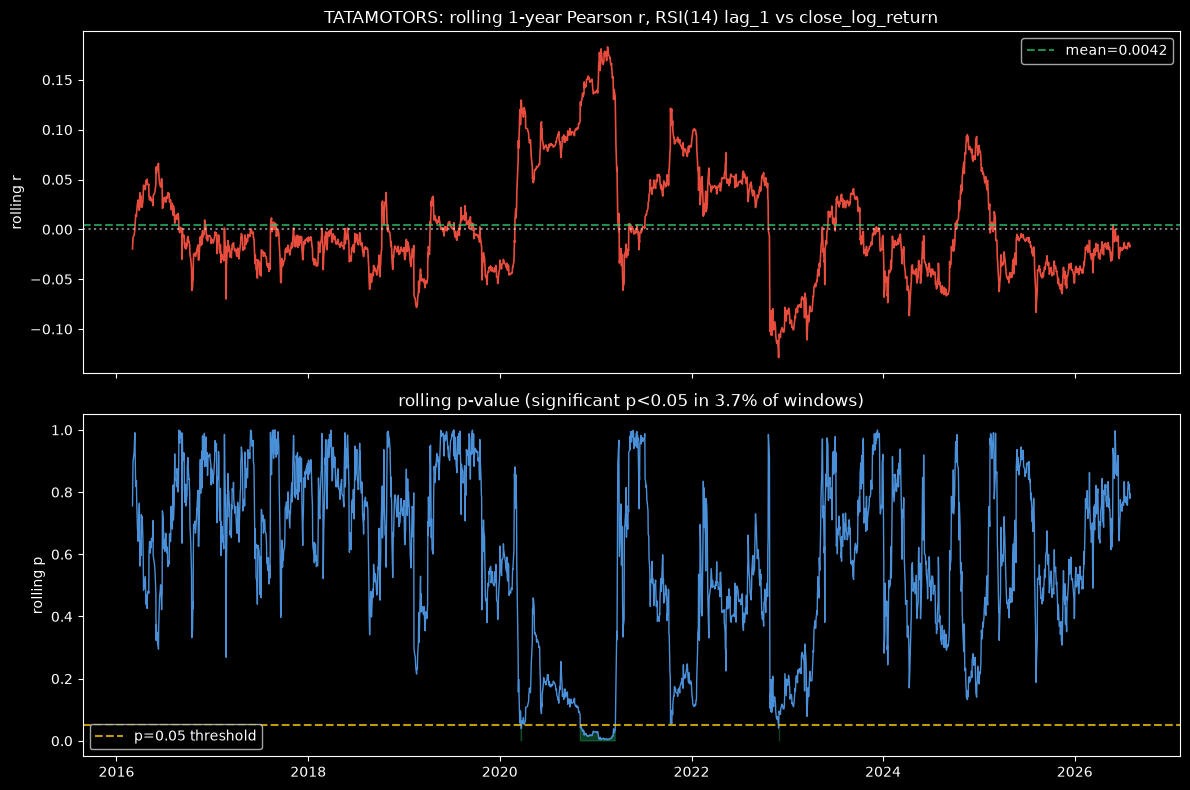

In [8]:
window = 252  # ~1 trading year
df_tata_full = tata.dropna(subset=['rsi_lag_1', 'close_log_return'])

roll_dates, roll_r, roll_p = [], [], []
for i in range(window, len(df_tata_full) + 1):
    chunk = df_tata_full.iloc[i - window:i]
    r, p = st.pearsonr(chunk['rsi_lag_1'], chunk['close_log_return'])
    roll_dates.append(df_tata_full.index[i - 1])
    roll_r.append(r)
    roll_p.append(p)

roll_tata = pd.DataFrame({'date': roll_dates, 'r': roll_r, 'p': roll_p})
sig_frac_tata = (roll_tata['p'] < 0.05).mean()
print('TATAMOTORS rolling 1yr r — min:', round(roll_tata.r.min(), 4), '| max:', round(roll_tata.r.max(), 4),
      '| mean:', round(roll_tata.r.mean(), 4), '| ever crosses 0:', (roll_tata.r < 0).any() and (roll_tata.r > 0).any())
print('windows with p<0.05:', f'{sig_frac_tata*100:.1f}%', '| median p:', round(roll_tata.p.median(), 4))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(roll_tata['date'], roll_tata['r'], color='#e74c3c', linewidth=1.2)
ax1.axhline(0, color='white', linestyle=':', alpha=0.5)
ax1.axhline(roll_tata['r'].mean(), color='#2ecc71', linestyle='--', alpha=0.7, label=f"mean={roll_tata['r'].mean():.4f}")
ax1.set_title('TATAMOTORS: rolling 1-year Pearson r, RSI(14) lag_1 vs close_log_return')
ax1.set_ylabel('rolling r')
ax1.legend()

ax2.plot(roll_tata['date'], roll_tata['p'], color='#4a90d9', linewidth=1.0)
ax2.axhline(0.05, color='#f1c40f', linestyle='--', alpha=0.8, label='p=0.05 threshold')
ax2.fill_between(roll_tata['date'], 0, roll_tata['p'], where=(roll_tata['p'] < 0.05), color='#2ecc71', alpha=0.3)
ax2.set_title(f'rolling p-value (significant p<0.05 in {sig_frac_tata*100:.1f}% of windows)')
ax2.set_ylabel('rolling p')
ax2.legend()

plt.tight_layout()
plt.show()

## INFY

In [9]:
bars = pd.read_parquet('../../../../data/historical/intraday_5min_DS3/INFY.parquet', columns=['datetime', 'close'])
bars['datetime'] = pd.to_datetime(bars['datetime'])
if bars['datetime'].dt.tz is not None:
    bars['datetime'] = bars['datetime'].apply(lambda x: x.replace(tzinfo=None))
bars['close'] = pd.to_numeric(bars['close'], errors='coerce')
bars.loc[bars['close'] <= 0, 'close'] = np.nan
infy = bars.set_index('datetime')['close'].resample('D').last().dropna().to_frame()
infy.rename(columns={'close': 'c'}, inplace=True)
infy = build_features(infy)

results_infy, train_infy = screen(infy, candidates)
print('INFY — Train n:', len(train_infy))
results_infy

INFY — Train n: 2088


,feature,n,r,p,significant (p<0.05)
0,close_log_return_lag_1,2088,-0.0165,0.4518,False
1,rsi_lag_1,2088,-0.0204,0.3505,False


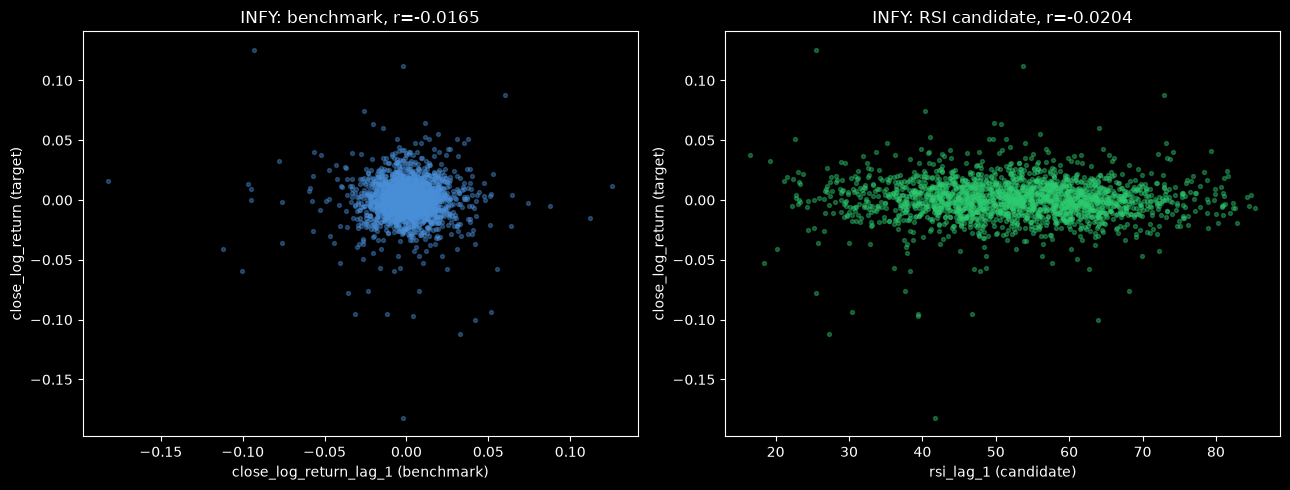

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(train_infy['close_log_return_lag_1'], train_infy['close_log_return'], s=8, alpha=0.4, color='#4a90d9')
axes[0].set_xlabel('close_log_return_lag_1 (benchmark)')
axes[0].set_ylabel('close_log_return (target)')
axes[0].set_title(f"INFY: benchmark, r={results_infy.loc[0,'r']}")

axes[1].scatter(train_infy['rsi_lag_1'], train_infy['close_log_return'], s=8, alpha=0.4, color='#2ecc71')
axes[1].set_xlabel('rsi_lag_1 (candidate)')
axes[1].set_ylabel('close_log_return (target)')
axes[1].set_title(f"INFY: RSI candidate, r={results_infy.loc[1,'r']}")
plt.tight_layout()
plt.show()

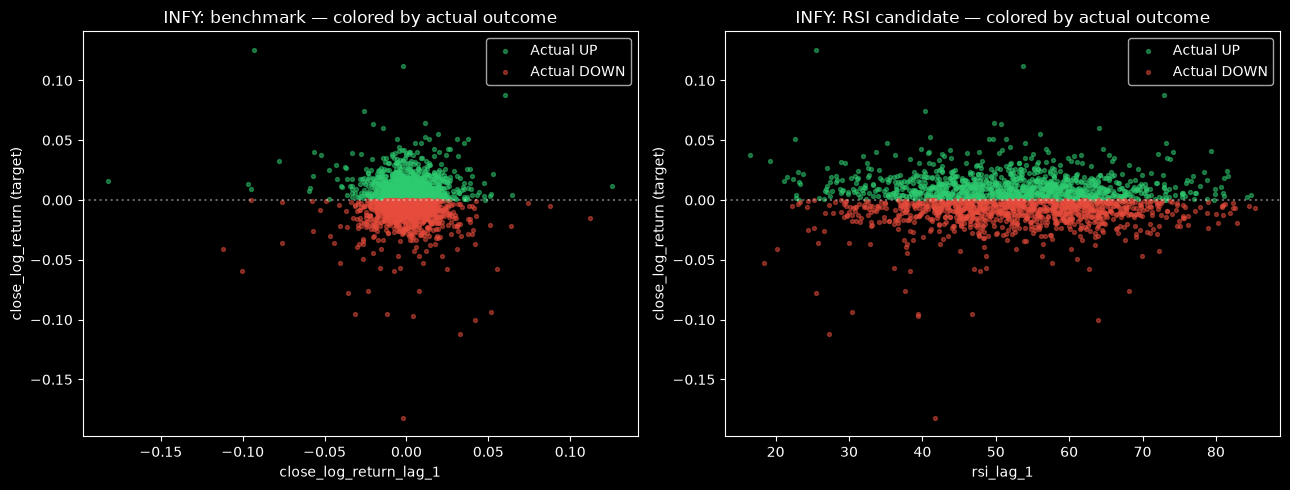

In [11]:
up_i = train_infy[train_infy['close_log_return'] > 0]
down_i = train_infy[train_infy['close_log_return'] <= 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat, title in [(axes[0], 'close_log_return_lag_1', 'benchmark'), (axes[1], 'rsi_lag_1', 'RSI candidate')]:
    ax.scatter(up_i[feat], up_i['close_log_return'], s=8, alpha=0.5, color='#2ecc71', label='Actual UP')
    ax.scatter(down_i[feat], down_i['close_log_return'], s=8, alpha=0.5, color='#e74c3c', label='Actual DOWN')
    ax.axhline(0, color='white', linestyle=':', alpha=0.4)
    ax.set_xlabel(feat)
    ax.set_ylabel('close_log_return (target)')
    ax.set_title(f'INFY: {title} — colored by actual outcome')
    ax.legend()
plt.tight_layout()
plt.show()

## POWERGRID

In [12]:
bars = pd.read_parquet('../../../../data/historical/intraday_5min_DS3/POWERGRID.parquet', columns=['datetime', 'close'])
bars['datetime'] = pd.to_datetime(bars['datetime'])
if bars['datetime'].dt.tz is not None:
    bars['datetime'] = bars['datetime'].apply(lambda x: x.replace(tzinfo=None))
bars['close'] = pd.to_numeric(bars['close'], errors='coerce')
bars.loc[bars['close'] <= 0, 'close'] = np.nan
pg = bars.set_index('datetime')['close'].resample('D').last().dropna().to_frame()
pg.rename(columns={'close': 'c'}, inplace=True)
pg = build_features(pg)

results_pg, train_pg = screen(pg, candidates)
print('POWERGRID — Train n:', len(train_pg))
results_pg

POWERGRID — Train n: 2097


,feature,n,r,p,significant (p<0.05)
0,close_log_return_lag_1,2097,-0.0584,0.0075,True
1,rsi_lag_1,2097,-0.0829,0.0001,True


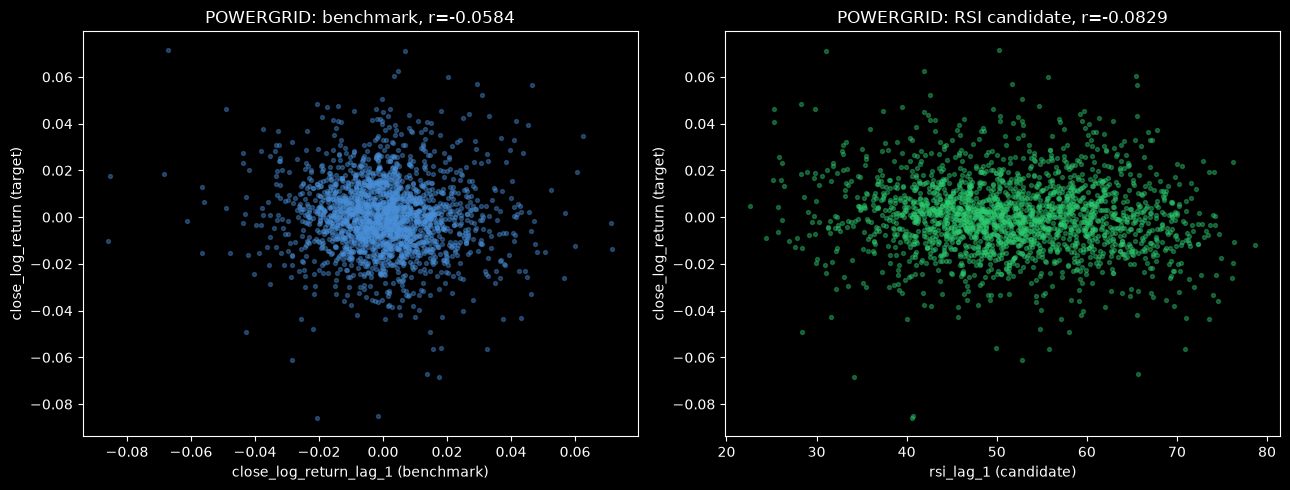

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(train_pg['close_log_return_lag_1'], train_pg['close_log_return'], s=8, alpha=0.4, color='#4a90d9')
axes[0].set_xlabel('close_log_return_lag_1 (benchmark)')
axes[0].set_ylabel('close_log_return (target)')
axes[0].set_title(f"POWERGRID: benchmark, r={results_pg.loc[0,'r']}")

axes[1].scatter(train_pg['rsi_lag_1'], train_pg['close_log_return'], s=8, alpha=0.4, color='#2ecc71')
axes[1].set_xlabel('rsi_lag_1 (candidate)')
axes[1].set_ylabel('close_log_return (target)')
axes[1].set_title(f"POWERGRID: RSI candidate, r={results_pg.loc[1,'r']}")
plt.tight_layout()
plt.show()

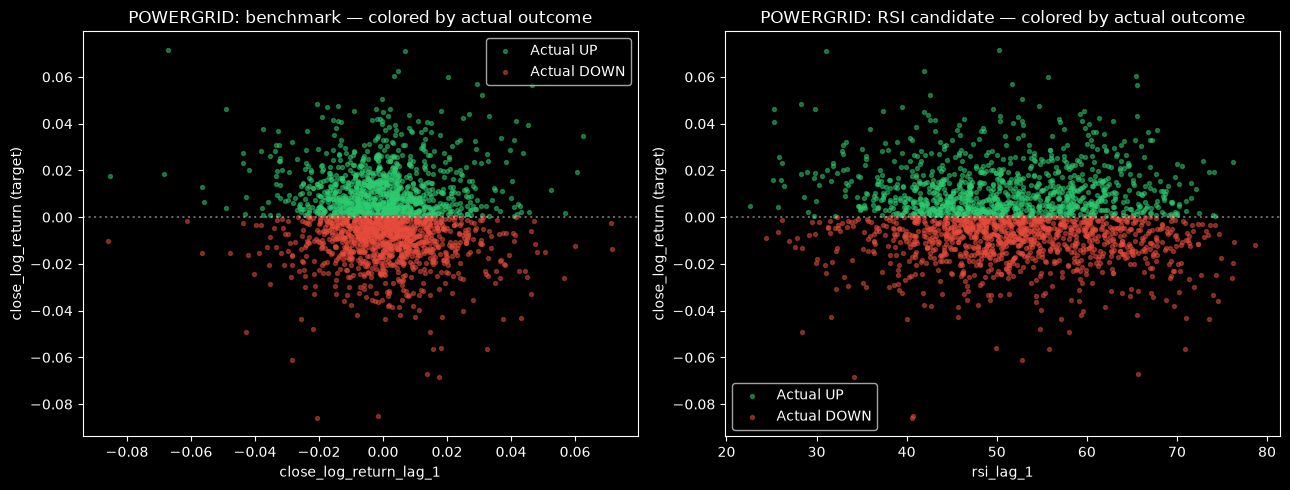

In [14]:
up_p = train_pg[train_pg['close_log_return'] > 0]
down_p = train_pg[train_pg['close_log_return'] <= 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat, title in [(axes[0], 'close_log_return_lag_1', 'benchmark'), (axes[1], 'rsi_lag_1', 'RSI candidate')]:
    ax.scatter(up_p[feat], up_p['close_log_return'], s=8, alpha=0.5, color='#2ecc71', label='Actual UP')
    ax.scatter(down_p[feat], down_p['close_log_return'], s=8, alpha=0.5, color='#e74c3c', label='Actual DOWN')
    ax.axhline(0, color='white', linestyle=':', alpha=0.4)
    ax.set_xlabel(feat)
    ax.set_ylabel('close_log_return (target)')
    ax.set_title(f'POWERGRID: {title} — colored by actual outcome')
    ax.legend()
plt.tight_layout()
plt.show()

### POWERGRID RSI — rolling-correlation stability check

The single-split scatter/r only shows the relationship averaged over one Train
window. Given this session's history of a single-event-driven fluke (the
NIFTY50-gate hypothesis, killed by the 2024-06-04 crash) and single-day data
artifacts (INFY, DIVISLAB), any candidate worth trusting should also show a
**stable** relationship across time, not just a significant one-shot p-value.
Computed Pearson r in rolling 1-year (252 trading day) windows across
POWERGRID's full 2015-2025 history, using the full dataset (not just Train) —
this is a diagnostic stability check, not a model decision.

POWERGRID rolling 1yr r — min: -0.1922 | max: -0.0101 | mean: -0.0939 | ever crosses 0: False
windows with p<0.05: 25.4% | median p: 0.1534


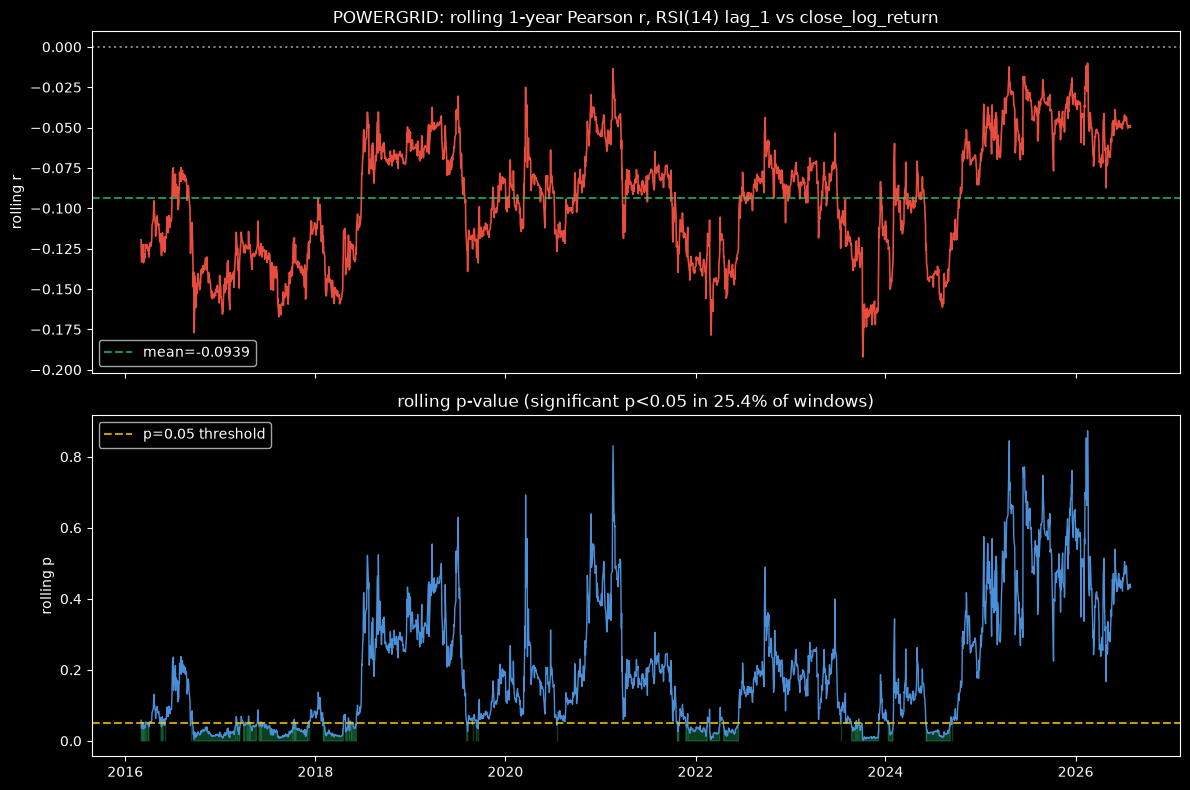

In [15]:
window = 252  # ~1 trading year
df_pg_full = pg.dropna(subset=['rsi_lag_1', 'close_log_return'])

roll_dates, roll_r, roll_p = [], [], []
for i in range(window, len(df_pg_full) + 1):
    chunk = df_pg_full.iloc[i - window:i]
    r, p = st.pearsonr(chunk['rsi_lag_1'], chunk['close_log_return'])
    roll_dates.append(df_pg_full.index[i - 1])
    roll_r.append(r)
    roll_p.append(p)

roll_pg = pd.DataFrame({'date': roll_dates, 'r': roll_r, 'p': roll_p})
sig_frac = (roll_pg['p'] < 0.05).mean()
print('POWERGRID rolling 1yr r — min:', round(roll_pg.r.min(), 4), '| max:', round(roll_pg.r.max(), 4),
      '| mean:', round(roll_pg.r.mean(), 4), '| ever crosses 0:', (roll_pg.r > 0).any())
print('windows with p<0.05:', f'{sig_frac*100:.1f}%', '| median p:', round(roll_pg.p.median(), 4))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(roll_pg['date'], roll_pg['r'], color='#e74c3c', linewidth=1.2)
ax1.axhline(0, color='white', linestyle=':', alpha=0.5)
ax1.axhline(roll_pg['r'].mean(), color='#2ecc71', linestyle='--', alpha=0.7, label=f"mean={roll_pg['r'].mean():.4f}")
ax1.set_title('POWERGRID: rolling 1-year Pearson r, RSI(14) lag_1 vs close_log_return')
ax1.set_ylabel('rolling r')
ax1.legend()

ax2.plot(roll_pg['date'], roll_pg['p'], color='#4a90d9', linewidth=1.0)
ax2.axhline(0.05, color='#f1c40f', linestyle='--', alpha=0.8, label='p=0.05 threshold')
ax2.fill_between(roll_pg['date'], 0, roll_pg['p'], where=(roll_pg['p'] < 0.05), color='#2ecc71', alpha=0.3)
ax2.set_title(f'rolling p-value (significant p<0.05 in {sig_frac*100:.1f}% of windows)')
ax2.set_ylabel('rolling p')
ax2.legend()

plt.tight_layout()
plt.show()

## Volume (TATAMOTORS only)

NIFTY50's own volume field is confirmed mostly-zero/meaningless (index, not a
traded instrument), so volume is only screened on TATAMOTORS. Daily volume =
sum of the day's 5-min bar volumes, lagged 1 day (raw indicator value, not a
log-return — same convention as RSI).

In [16]:
bars = pd.read_parquet('../../../../data/historical/intraday_5min_DS3/TATAMOTORS.parquet', columns=['datetime', 'close', 'volume'])
bars['datetime'] = pd.to_datetime(bars['datetime'])
if bars['datetime'].dt.tz is not None:
    bars['datetime'] = bars['datetime'].apply(lambda x: x.replace(tzinfo=None))
bars['close'] = pd.to_numeric(bars['close'], errors='coerce')
bars.loc[bars['close'] <= 0, 'close'] = np.nan

daily_close = bars.set_index('datetime')['close'].resample('D').last().dropna()
daily_volume = bars.set_index('datetime')['volume'].resample('D').sum()

tata_vol = pd.concat([daily_close.rename('c'), daily_volume.rename('volume')], axis=1).dropna(subset=['c'])
tata_vol['close_log_return'] = np.log(tata_vol['c'] / tata_vol['c'].shift())
tata_vol['close_log_return_lag_1'] = tata_vol['close_log_return'].shift()          # benchmark
tata_vol['volume_lag_1'] = tata_vol['volume'].shift()                              # candidate

vol_candidates = ['close_log_return_lag_1', 'volume_lag_1']
results_tata_vol, train_tata_vol = screen(tata_vol, vol_candidates)
print('TATAMOTORS (volume) — Train n:', len(train_tata_vol))
results_tata_vol

TATAMOTORS (volume) — Train n: 2106


/tmp/ipykernel_2364953/2567246735.py:11: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  tata_vol = pd.concat([daily_close.rename('c'), daily_volume.rename('volume')], axis=1).dropna(subset=['c'])


,feature,n,r,p,significant (p<0.05)
0,close_log_return_lag_1,2106,-0.0086,0.6946,False
1,volume_lag_1,2106,0.0182,0.4035,False


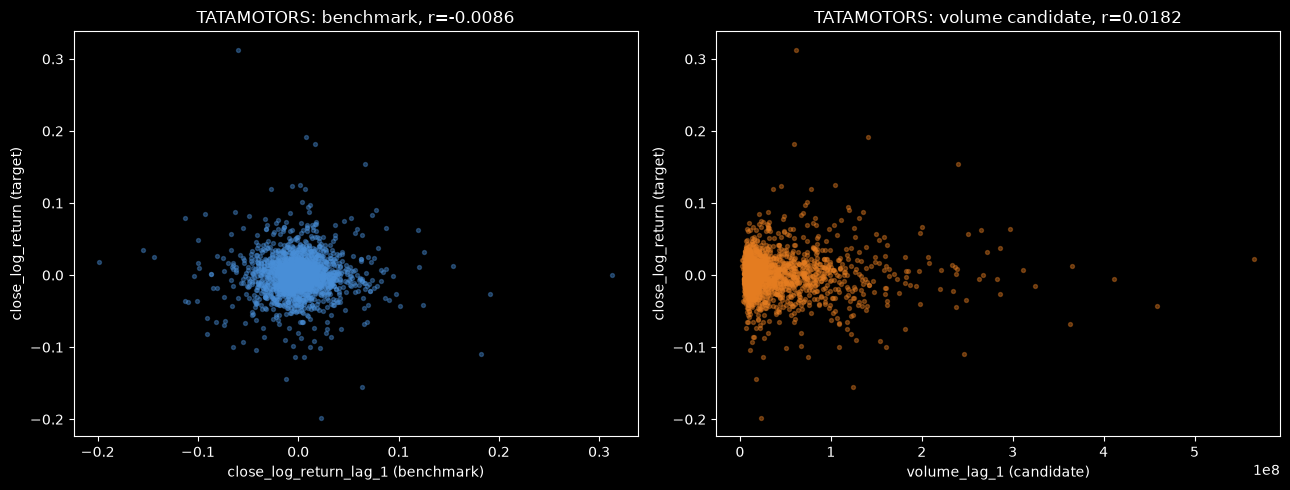

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(train_tata_vol['close_log_return_lag_1'], train_tata_vol['close_log_return'], s=8, alpha=0.4, color='#4a90d9')
axes[0].set_xlabel('close_log_return_lag_1 (benchmark)')
axes[0].set_ylabel('close_log_return (target)')
axes[0].set_title(f"TATAMOTORS: benchmark, r={results_tata_vol.loc[0,'r']}")

axes[1].scatter(train_tata_vol['volume_lag_1'], train_tata_vol['close_log_return'], s=8, alpha=0.4, color='#e67e22')
axes[1].set_xlabel('volume_lag_1 (candidate)')
axes[1].set_ylabel('close_log_return (target)')
axes[1].set_title(f"TATAMOTORS: volume candidate, r={results_tata_vol.loc[1,'r']}")
plt.tight_layout()
plt.show()

**Note for future model-combining (Model B):** volume's scatter shape looks very
different from RSI's — RSI is bounded (0-100) and fairly evenly spread, while raw
volume is heavily right-skewed (most days low-moderate, a long tail of a few
extreme high-volume days). A handful of outlier days can dominate a linear
regression's coefficient for volume even if the bulk of the data shows nothing.
If volume is ever combined with RSI (or anything else) in a Model B, it likely
needs a transform first (log of the level, or a ratio to its own rolling
average, i.e. "how unusual is today's volume") rather than being fed in raw.
Separately: the scatter shape of one feature vs the target doesn't tell you
whether two features carry independent information worth combining — that
needs a feature-vs-feature correlation check, not done yet.

## Gap-size (TATAMOTORS + POWERGRID)

`gap_size = log(open_today / close_yesterday)` — the overnight/pre-market move.

Important methodology note: `close_log_return` decomposes exactly into
`gap_size + intraday_move` (where `intraday_move = log(close_today/open_today)`).
Testing today's `gap_size` directly against `close_log_return` would be
mechanically biased (gap is literally an additive component of the target).
Testing `gap_size` against `intraday_move` instead has a *different* problem:
both formulas share the literal same `open_today` value with opposite signs,
which mechanically induces a **spurious negative correlation** even under zero
real relationship (a shared price point's own noise cancels between the two).

Fix: use the same lag-by-1-day discipline as every other candidate. Candidate
= **yesterday's** gap_size (`log(open_yesterday / close_2_days_ago)`), target
stays the standard `close_log_return` (today's close vs yesterday's close).
No literal shared price point between predictor and target this way.

In [18]:
bars = pd.read_parquet('../../../../data/historical/intraday_5min_DS3/TATAMOTORS.parquet', columns=['datetime', 'open', 'close'])
bars['datetime'] = pd.to_datetime(bars['datetime'])
if bars['datetime'].dt.tz is not None:
    bars['datetime'] = bars['datetime'].apply(lambda x: x.replace(tzinfo=None))
bars['open'] = pd.to_numeric(bars['open'], errors='coerce')
bars['close'] = pd.to_numeric(bars['close'], errors='coerce')
bars.loc[bars['open'] <= 0, 'open'] = np.nan
bars.loc[bars['close'] <= 0, 'close'] = np.nan

daily_open = bars.set_index('datetime')['open'].resample('D').first()
daily_close = bars.set_index('datetime')['close'].resample('D').last()
tata_gap = pd.concat([daily_open.rename('open'), daily_close.rename('close')], axis=1).dropna()
tata_gap['close_log_return'] = np.log(tata_gap['close'] / tata_gap['close'].shift())
tata_gap['gap_size'] = np.log(tata_gap['open'] / tata_gap['close'].shift())
tata_gap['gap_size_lag_1'] = tata_gap['gap_size'].shift()

gap_candidates = ['gap_size_lag_1']
results_tata_gap, train_tata_gap = screen(tata_gap, gap_candidates)
print('TATAMOTORS (gap-size) — Train n:', len(train_tata_gap))
results_tata_gap

TATAMOTORS (gap-size) — Train n: 2106


,feature,n,r,p,significant (p<0.05)
0,gap_size_lag_1,2106,0.0404,0.0636,False


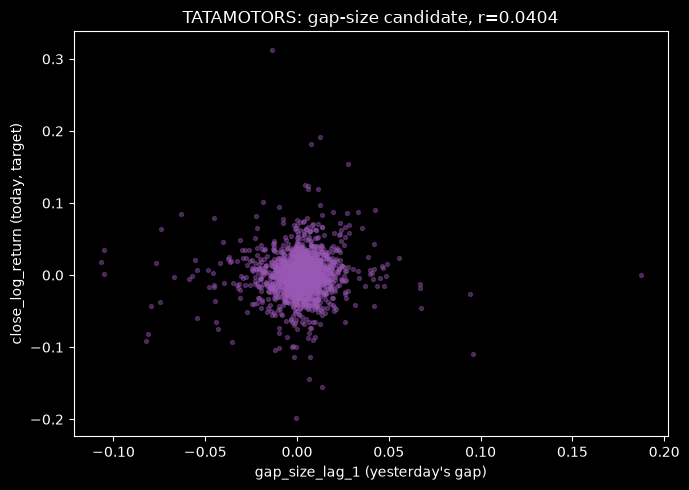

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train_tata_gap['gap_size_lag_1'], train_tata_gap['close_log_return'], s=8, alpha=0.4, color='#9b59b6')
ax.set_xlabel("gap_size_lag_1 (yesterday's gap)")
ax.set_ylabel('close_log_return (today, target)')
ax.set_title(f"TATAMOTORS: gap-size candidate, r={results_tata_gap.loc[0,'r']}")
plt.tight_layout()
plt.show()

In [20]:
bars = pd.read_parquet('../../../../data/historical/intraday_5min_DS3/POWERGRID.parquet', columns=['datetime', 'open', 'close'])
bars['datetime'] = pd.to_datetime(bars['datetime'])
if bars['datetime'].dt.tz is not None:
    bars['datetime'] = bars['datetime'].apply(lambda x: x.replace(tzinfo=None))
bars['open'] = pd.to_numeric(bars['open'], errors='coerce')
bars['close'] = pd.to_numeric(bars['close'], errors='coerce')
bars.loc[bars['open'] <= 0, 'open'] = np.nan
bars.loc[bars['close'] <= 0, 'close'] = np.nan

daily_open = bars.set_index('datetime')['open'].resample('D').first()
daily_close = bars.set_index('datetime')['close'].resample('D').last()
pg_gap = pd.concat([daily_open.rename('open'), daily_close.rename('close')], axis=1).dropna()
pg_gap['close_log_return'] = np.log(pg_gap['close'] / pg_gap['close'].shift())
pg_gap['gap_size'] = np.log(pg_gap['open'] / pg_gap['close'].shift())
pg_gap['gap_size_lag_1'] = pg_gap['gap_size'].shift()

results_pg_gap, train_pg_gap = screen(pg_gap, gap_candidates)
print('POWERGRID (gap-size) — Train n:', len(train_pg_gap))
results_pg_gap

POWERGRID (gap-size) — Train n: 2106


,feature,n,r,p,significant (p<0.05)
0,gap_size_lag_1,2106,-0.0295,0.1763,False


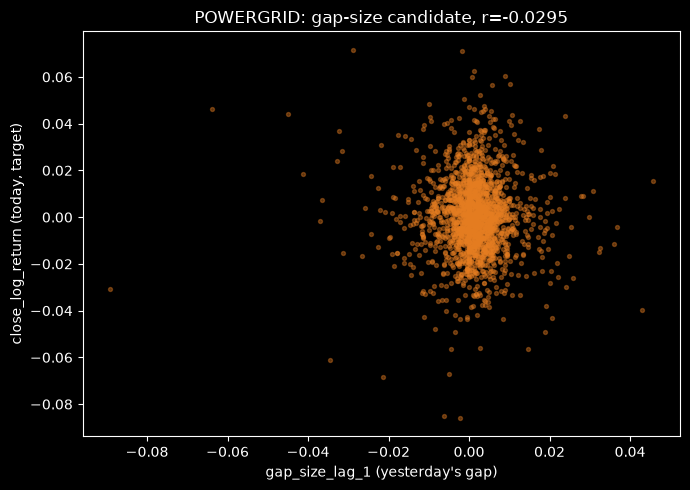

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train_pg_gap['gap_size_lag_1'], train_pg_gap['close_log_return'], s=8, alpha=0.4, color='#e67e22')
ax.set_xlabel("gap_size_lag_1 (yesterday's gap)")
ax.set_ylabel('close_log_return (today, target)')
ax.set_title(f"POWERGRID: gap-size candidate, r={results_pg_gap.loc[0,'r']}")
plt.tight_layout()
plt.show()

## Summary — all four instruments side by side

In [22]:
summary = pd.concat([
    results_nifty.assign(instrument='NIFTY50'),
    results_tata.assign(instrument='TATAMOTORS'),
    results_infy.assign(instrument='INFY'),
    results_pg.assign(instrument='POWERGRID'),
    results_tata_vol.assign(instrument='TATAMOTORS (volume)'),
    results_tata_gap.assign(instrument='TATAMOTORS (gap-size)'),
    results_pg_gap.assign(instrument='POWERGRID (gap-size)'),
])[['instrument', 'feature', 'n', 'r', 'p', 'significant (p<0.05)']]
summary

,instrument,feature,n,r,p,significant (p<0.05)
0,NIFTY50,close_log_return_lag_1,2123,-0.0204,0.3465,False
1,NIFTY50,rsi_lag_1,2123,0.0212,0.3281,False
0,TATAMOTORS,close_log_return_lag_1,2097,-0.0087,0.6888,False
1,TATAMOTORS,rsi_lag_1,2097,0.0548,0.0120,True
0,INFY,close_log_return_lag_1,2088,-0.0165,0.4518,False
1,INFY,rsi_lag_1,2088,-0.0204,0.3505,False
0,POWERGRID,close_log_return_lag_1,2097,-0.0584,0.0075,True
1,POWERGRID,rsi_lag_1,2097,-0.0829,0.0001,True
0,TATAMOTORS (volume),close_log_return_lag_1,2106,-0.0086,0.6946,False
1,TATAMOTORS (volume),volume_lag_1,2106,0.0182,0.4035,False
